## Домашнее задание №3 (курс "Практикум по программированию на языке Python")

### Выполнил: <font color='red'>AAA, AAA, AAA</font>

### Тема: Основы работы с искусственными нейронными сетями

#### Преподаватель: Мурат Апишев (mel-lain@yandex.ru)

**Выдана**:   10 апреля 2025

**Дедлайн**:   21:00 30 апреля 2025

**Среда выполнения**: Jupyter Notebook (Python 3.10+)

#### Правила:

Результат выполнения задания - Jupyter Notebook с кодом и подробными ответами в случае теоретических вопросов. __Максимальное число баллов за задание - 30__.

Все ячейки должны быть "выполненными", при этом результат должен воспроизводиться при проверке (на Python 3.10). Если какой-то код не был запущен или отрабатывает с ошибками, то пункт не засчитывается. Задание, сданное после дедлайна, _не принимается_. Можно отправить недоделанное задание, выполненные пункты будут оценены.

Готовое задание отправляется на почту mel-lain@yandex.ru.

Задание выполняется самостоятельно. Если какие-то студенты будут уличены в списывании, все они автоматически получат за эту работу 0 баллов. Если вы нашли в Интернете какой-то специфичный код, который собираетесь заимствовать, обязательно укажите это в задании - наверняка вы не единственный, кто найдёт и использует эту информацию. <font color='blue'>Для решения задач этой лабораторной работы запрещается использовать любые приложения/API для генерации кода на основе LLM.</font>

__Удалять фрагменты формулировок заданий запрещается.__

#### Постановка задачи:

- В данной работе нужно решить задачи векторизации и классификации текстов несколькими способами с помощью нейросетевых моделей и сравнить между собой.
- Даже если это не указано явно в требованиях, код должен быть по возможности неизбыточным, работать с разумной сложностью и объёмом потребляемой памяти, проверяющие могут снизить балл за задание, выполненное без учёта этого требования.
- Результирующий код должен быть читаемым, с единой системой отступов и адеквантными названиями переменных, проверяющие могут снизить балл за задание, выполненное без учёта этого требования.
- Везде, где это требуется, должны быть отрисованы необходимые графики и даны комментарии и выводы.
- Для выполнения задания потребуется машина с GPU, если его нет на своем ноутбуке/ПК, можно использовать Google Colab
- __Любая ячейка кода в задании (кроме обучения базовой лог-регрессии) при реализации в векторном виде и запуске на поддерживающей этот код GPU не должна выполняться более получаса, большая часть кода должна выполняться быстрее__

импорты

In [1]:
#!pip install "transformers==4.36.0"
#!pip install "numpy<2" --user --force-reinstall
import time
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import normalize
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
import transformers
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader, Dataset
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

/home/a.bulkin/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Для выполнения задания нужно загрузить набор данных для задачи multi-label классификации текстов EURLex (только английскую часть) следующим кодом:

In [2]:
#!pip uninstall  datasets -y
#!pip install -q "datasets==3.6.0"
import datasets
print(datasets.__version__)
print(transformers.__version__) 

3.6.0
4.36.0


In [3]:
from datasets import load_dataset
dataset = load_dataset('multi_eurlex', 'en')

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /datasets/multi_eurlex/resolve/main/README.md (Caused by NewConnectionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to establish a new connection: [Errno 101] Network is unreachable"))'), '(Request ID: 69476375-9f4f-4fa3-a7eb-e6da1ac492d6)')' thrown while requesting HEAD https://huggingface.co/datasets/multi_eurlex/resolve/main/README.md
Retrying in 1s [Retry 1/5].


PS: пришлось откатить версию `datasets`, чтобы скачать данные, так как для запуска датасета нужны скрипты, которые уже не поддерживаются

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['celex_id', 'text', 'labels'],
        num_rows: 55000
    })
    test: Dataset({
        features: ['celex_id', 'text', 'labels'],
        num_rows: 5000
    })
    validation: Dataset({
        features: ['celex_id', 'text', 'labels'],
        num_rows: 5000
    })
})

__Задание 1 (5 баллов):__ Самый простой способ выучить модель классификации - использовать лог-регрессию на сжатых плотных векторах документов. Для этого нужно выполнить ряд подзадач.

Преобразовать данные в векторный вид с помощью `CountVectorizer` и `TruncatedSVD`:

Достанем тексты:

In [5]:
train_texts = dataset['train']['text']
valid_texts = dataset['validation']['text']
test_texts = dataset['test']['text']
train_texts[0][:30]

'COMMISSION DECISION\nof 6 March'

Для векторизации [используем](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) `max_df` и `min_df` для отбрасывания слишком частых и редких слов (можно указывать по числу слов, можно по частоте):

In [9]:
vectorizer = CountVectorizer(max_features=30000, min_df=4, max_df=0.9)
X_train = vectorizer.fit_transform(train_texts)
X_valid = vectorizer.transform(valid_texts)
X_test= vectorizer.transform(test_texts)

Теперь используем SVD разложение как в прошлом ДЗ:

In [72]:
svd = TruncatedSVD(n_components=100,n_iter=10)

`n_iter` отвечает за количество итераций рандомизированного SVD

Учимся только на тренировочных данных, преобразуем все

In [73]:
X_train = svd.fit_transform(normalize(X_train))

In [74]:
X_valid = svd.transform(normalize(X_valid))

In [75]:
X_test= normalize(svd.transform(X_test))

Еще добавлена нормализация, иначе в SVD возникает переполнение

Посмотрим, какие размеры получились у данных:

In [76]:
X_train.shape, X_valid.shape, X_test.shape

((55000, 100), (5000, 100), (5000, 100))

Конвертировать метки классов в вид бинарной матрицы с размером "число объектов" на "число классов":

Посчитаем, сколько всего классов:

In [11]:
dataset['train']['labels'][0]

[1, 20, 7, 3, 0]

In [6]:
num_classes = max(max(labels) for labels in dataset['train']['labels']) + 1
num_classes

21

Теперь напишем функцию для перевода меток в нужный формат:

In [7]:
def binarize(labels_list, num_classes = num_classes):
    matrix = np.zeros((len(labels_list), num_classes))
    for i, labels in enumerate(labels_list):
        matrix[i, labels] = 1
    return matrix

Проверим:

In [8]:
binarize(dataset['train']['labels']).shape

(55000, 21)

In [9]:
y_train = binarize(dataset['train']['labels'])
y_valid = binarize(dataset['validation']['labels'])
y_test = binarize(dataset['test']['labels'])

Обучить мета-модель на основе лог-регрессии с помощью `MultiOutputClassifier`:

Из [документации](https://scikit-learn.org/stable/modules/generated/sklearn.multioutput.MultiOutputClassifier.html):
>Multi target classification.
>
>This strategy consists of fitting one classifier per target. This is a simple strategy for >extending classifiers that do not natively support multi-target classification.

In [82]:
base_lr = LogisticRegression(C=1, max_iter=1000)
model = MultiOutputClassifier(base_lr, n_jobs=-1)

Обучение и предсказания:

In [83]:
model.fit(X_train, y_train)

y_pred_valid = model.predict(X_valid)
y_pred_test = model.predict(X_test)

Описать функцию подбора оптимальных порогов бинаризации для каждого класса и подобрать их для модели на валидационной выборке:

Будем действовать жадным алгоритмом:
- Перебираем пороги каждого класса по очереди
- Уже зафиксировав прошлые пороги, для данного класса смотрим как меняется F1 (macro или micro) на валидационной выборке. Там, где еще не подобрали, ставим деволтный порог 0.5

In [10]:
def calculate_best_thresholds(model, X_valid, y_valid, average='macro', step=0.1):
    best_thresholds = []

    # Вероятности
    proba = np.array([est.predict_proba(X_valid)[:, 1] for est in model.estimators_]).T

    # Перебор
    for class_id in range(y_valid.shape[1]):
        best_f1 =-1
        best_thresh = 0.5

        for thresh in np.arange(step, 1.0, step):
            y_pred = proba.copy()
            y_pred_binary = (y_pred >= np.array(
                best_thresholds + [thresh] + [0.5] * (y_valid.shape[1] - class_id - 1)))
            f1 = f1_score(y_valid, y_pred_binary, average=average)

            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        best_thresholds = [round(t, 4) for t in best_thresholds]
    return best_thresholds

Подберем пороги:

In [85]:
best_thresholds = calculate_best_thresholds(model, X_valid, y_valid, average='macro', step=0.1)
best_thresholds

[np.float64(0.3),
 np.float64(0.2),
 np.float64(0.6),
 np.float64(0.4),
 np.float64(0.4),
 np.float64(0.4),
 np.float64(0.3),
 np.float64(0.2),
 np.float64(0.3),
 np.float64(0.2),
 np.float64(0.2),
 np.float64(0.2),
 np.float64(0.2),
 np.float64(0.1),
 np.float64(0.1),
 np.float64(0.5),
 np.float64(0.1),
 np.float64(0.4),
 np.float64(0.4),
 np.float64(0.2),
 np.float64(0.2)]

In [86]:
best_thresholds = calculate_best_thresholds(model, X_valid, y_valid, average='micro', step=0.1)
best_thresholds

[np.float64(0.3),
 np.float64(0.2),
 np.float64(0.3),
 np.float64(0.4),
 np.float64(0.4),
 np.float64(0.4),
 np.float64(0.3),
 np.float64(0.3),
 np.float64(0.3),
 np.float64(0.9),
 np.float64(0.5),
 np.float64(0.3),
 np.float64(0.3),
 np.float64(0.4),
 np.float64(0.2),
 np.float64(0.5),
 np.float64(0.4),
 np.float64(0.4),
 np.float64(0.4),
 np.float64(0.2),
 np.float64(0.2)]

Описать код применения модели и порогов к выходным вероятностям для получения значений F1-меры с micro и macro усреднениями и вычислить их на тестовой выборке. Для получения максимального балла код этого подзадания должен быть написан в векторном виде с помощью NumPy, без циклов:

Просто для каждой модели предскажем пороги на нужном срезе (надо транспонировать для правильных размерностей), после этого ставим предсказания по трешхолдам

In [87]:
proba_test = np.array([est.predict_proba(X_test)[:, 1] for est in model.estimators_]).T

y_test_pred = (proba_test >= np.array(best_thresholds))

print(f"F1-macro: {f1_score(y_test, y_test_pred, average='macro'):.2f}")
print(f"F1-micro: {f1_score(y_test, y_test_pred, average='micro'):.2f}")

F1-macro: 0.52
F1-micro: 0.67


Провести набор запусков с различными комбинациями размера словаря `CountVectorizer` и числа компонент в `TruncatedSVD` и оценить их влияние на качество на текстовой выборке

- попробовать нужно как минимум 3 существенно различных значения для каждого параметра
- результаты должны быть представлены наглядно в виде таблиц и сделанных на их основе выводов

Обернем прошлые действия в цикл по различным размерам словаря и числам компонент SVD разложения:

In [97]:
max_features_list = [500, 5000, 20000, 50000]
n_components_list = [50, 100, 200]
results = []

Будем подбирать трешхолды по микро и макро F1

In [98]:
for max_features in max_features_list:
    for n_components in n_components_list:
        print(f'\nmax_features={max_features}, n_components={n_components}')
        # Векторизация
        vectorizer = CountVectorizer(max_features=max_features, min_df=3, max_df=0.9)
        X_train = normalize(vectorizer.fit_transform(train_texts))
        X_valid = normalize(vectorizer.transform(valid_texts))
        X_test= normalize(vectorizer.transform(test_texts))
        
        # SVD
        svd = TruncatedSVD(n_components=n_components)
        X_train = svd.fit_transform(X_train)
        X_valid = svd.transform(X_valid)
        X_test= svd.transform(X_test)

        # Модель
        model = MultiOutputClassifier(LogisticRegression(C=1, max_iter=1000), n_jobs=-1)
        model.fit(X_train, y_train)

         # Пороги по macro
        thresholds_macro = calculate_best_thresholds(model, X_valid, y_valid, average='macro')

        # Пороги по micro
        thresholds_micro = calculate_best_thresholds(model, X_valid, y_valid, average='micro')

        # Предсказание
        proba_test = np.array([est.predict_proba(X_test)[:, 1] for est in model.estimators_]).T
        y_pred_macro = (proba_test >= thresholds_macro)
        y_pred_micro = (proba_test >= thresholds_micro)
        
        results.append({
            'max_features': max_features,
            'n_components': n_components,
            'F1-macro (macro t)': round(f1_score(y_test, y_pred_macro, average='macro'), 4),
            'F1-micro (macro t)': round(f1_score(y_test, y_pred_macro, average='micro'), 4),
            'F1-macro (micro t)': round(f1_score(y_test, y_pred_micro, average='macro'), 4),
            'F1-micro (micro t)': round(f1_score(y_test, y_pred_micro, average='micro'), 4)})


max_features=500, n_components=50

max_features=500, n_components=100

max_features=500, n_components=200

max_features=5000, n_components=50

max_features=5000, n_components=100

max_features=5000, n_components=200

max_features=20000, n_components=50

max_features=20000, n_components=100

max_features=20000, n_components=200

max_features=50000, n_components=50

max_features=50000, n_components=100

max_features=50000, n_components=200


Посмотрим результаты:

In [99]:
results_df = pd.DataFrame(results)
results_df

,max_features,n_components,F1-macro (macro t),F1-micro (macro t),F1-macro (micro t),F1-micro (micro t)
0,500,50,0.4596,0.6021,0.3976,0.6324
1,500,100,0.5002,0.6424,0.4653,0.6736
2,500,200,0.5292,0.6644,0.4831,0.7063
3,5000,50,0.4718,0.6051,0.4170,0.6455
4,5000,100,0.5320,0.6681,0.4982,0.6900
5,5000,200,0.5614,0.6956,0.5424,0.7307
6,20000,50,0.4721,0.5950,0.4129,0.6588
7,20000,100,0.5286,0.6599,0.5035,0.6903
8,20000,200,0.5615,0.6930,0.5385,0.7198
9,50000,50,0.4781,0.6063,0.4087,0.6581


Посмотрим распределение классов:

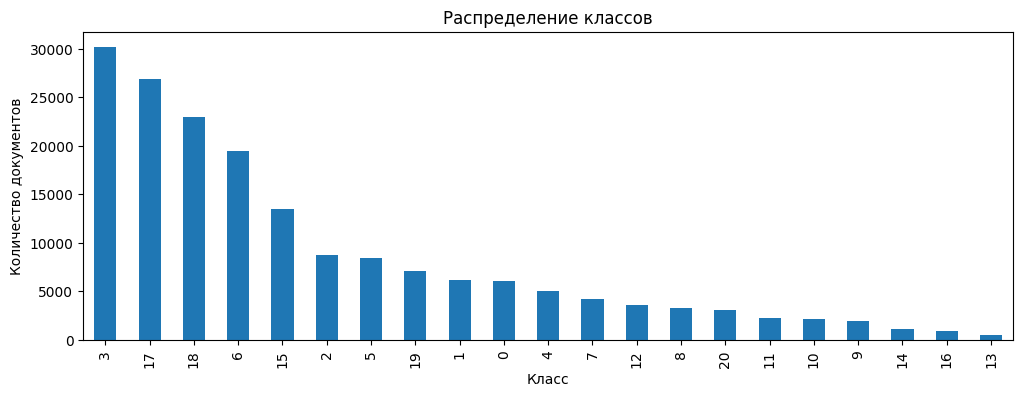

In [96]:
class_counts = y_train.sum(axis=0)

pd.Series(class_counts).sort_values(ascending=False).plot(kind='bar', figsize=(12, 4))
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество документов')
plt.show()

**Выводы**
- Пороги можно оценивать как по микро, так и по макро усреднению, макро усреднее хорошее тогда, когда все классы одинаково важны (все классы весят одинаково). Микро усреднее считает классы пропорционально. В данной задаче классы распределены не равномерно, поэтому, я думаю, макро усреднение оптимальней
- Число компонент в SVD сильно влияет на результаты, это связано с тем, что таким образом лучше сохраняется информация о тексте
- Максимальное число признаков не так сильно влияет, словаря от 5000 компонент оказывается уже достаточно
- Лучшая конфигурация - 200 компонент SVD и 5000 признаков
- Интересно, что без нормализации, когда я раньше запускал, результаты получались получше, но было переполнение и модели работали нестабильно

__Задание 2 (5 баллов):__ Заменить метод векторизации документов для модели выше на BERT.

Описать код класса BERTVectorizer, который должен уметь обрабатывать данные в батчевом режиме на заданном устройстве. Должно быть предусмотрено 2 режима формирования векторов документов - на основе CLS-токена и на основе усреднения всех выходных векторов (тут нужно использовать поле `attention_mask` и игнорировать векторы токенов паддинга, для которых в маске записан 0):

- Для работы класса будем использовать `AutoTokenizer`, как на лекции (07-nn), в `__init__` так же загружаем с помощью `AutoModel`
- В вызове веторизации просто батчированно обрабатываем данные
- Для получения векторов из модели берем параметры через `last_hidden_state`, токенайзер настроим везде одинаково

Если токенизировать на CPU перед каждым батчем, то получится слишком долго, поэтому придется написать свой датасет:

In [10]:
class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = list(texts)
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx]

Будем его использовать в векторизации при вызове, еще нужен даталоадер, у которого укажем 4 воркера, потому что, как видно по статистике, CPU долго полностью загружен

В векторизации оборачиваем модель в `DataParallel`, потому что у меня несколько GPU на kaggle:

In [11]:
class BERTVectorizer:
    def __init__(self, model_name, batch_size=64, device='cuda:0'):
        self.batch_size = batch_size
        self.device = device
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.model = nn.DataParallel(self.model).to(device)
        self.model.eval()

    def __call__(self, texts, averaging='cls'): # 'cls' | 'mean'

        def collate_fn(batch_texts):
            return self.tokenizer(
                batch_texts, padding=True, truncation=True,
                max_length=256, return_tensors='pt'
            )
        
        # Датасет и лоадер
        dataset = TextDataset(texts)
        loader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            collate_fn=collate_fn,
            num_workers= 2
        )
        
        embeddings = []
        
        with torch.no_grad():
            for batch in tqdm(loader, desc ='Векторизация', leave =False):
                batch = {k: v.to(self.device) for k, v in batch.items()}
                batch_embeddings = self._vectorize_batch(batch, averaging)
                embeddings.append(batch_embeddings)
        return np.vstack(embeddings)

    def _vectorize_batch(self, texts, averaging):
        output = self.model(**texts)
        hidden_states = output.last_hidden_state
        if averaging == 'cls':
            batch_embeddings = hidden_states[:, 0, :]
        elif averaging == 'mean':
            mask = texts['attention_mask'].unsqueeze(-1)
            sum_embeddings = (hidden_states * mask).sum(dim=1)
            num_tokens = mask.sum(dim=1)
            batch_embeddings = sum_embeddings / num_tokens
        return batch_embeddings.cpu().numpy()

Использовать его для векторизации данных с помощью модели `cointegrated/rubert-tiny2`:

Загрузим модель:

In [12]:
vectorizer = BERTVectorizer('cointegrated/rubert-tiny2')

/home/a.bulkin/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Попробуем векторизовать:

In [16]:
X_train = vectorizer(dataset['train']['text'], averaging='cls')
X_valid = vectorizer(dataset['validation']['text'], averaging='cls')
X_test = vectorizer(dataset['test']['text'], averaging='cls')

X_train.shape

del X_train
del X_valid
del X_test

Векторизация:   0%|          | 0/860 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Описать код сохранения/загрузки векторов с диска:

- Будем сохранять файлики с помощью numpy, так как это векторы, [сохраняются](https://numpy.org/devdocs/reference/generated/numpy.save.html) в формате `.npy`

In [20]:
def save_embeddings(path, names, arrays):
    os.makedirs(path, exist_ok=True)
    for name, array in zip(names, arrays):
        np.save(os.path.join(path, f'{name}.npy'), array)

def load_embeddings(path, names):
    return [np.load(os.path.join(path, f'{name}.npy')) for name in names]

Повторить обучение модели и замер качества из п.1 на новых векторах:

Сразу сделаем через функцию, чтобы переиспользовать в следующем пункте для других моделей:

In [19]:
def test_vectorizers(vectorizer):
    results_bert =[]
    for averaging in tqdm(['cls', 'mean']):
        print(f'Усреднение: {averaging}')

        # Векторизация
        X_train_bert = vectorizer(dataset['train']['text'], averaging=averaging)
        X_valid_bert = vectorizer(dataset['validation']['text'], averaging=averaging)
        X_test_bert = vectorizer(dataset['test']['text'], averaging=averaging)

        # Сохранние
        save_embeddings(f'embeddings/{averaging}',
            names=['X_train', 'X_valid', 'X_test'],
            arrays=[X_train_bert, X_valid_bert, X_test_bert])

        # Модель
        model = MultiOutputClassifier(LogisticRegression(C=1, max_iter=1000), n_jobs=-1)
        model.fit(X_train_bert, y_train)

        for average in ['macro', 'micro']:
            # Пороги
            thresholds = calculate_best_thresholds(model, X_valid_bert, y_valid, average=average)
            thresholds = np.round(thresholds, 2)

            # Предикт
            proba_test = np.array([est.predict_proba(X_test_bert)[:, 1] for est in model.estimators_]).T
            y_test_pred =(proba_test >= thresholds)
            results_bert.append({
                'averaging': averaging,
                'thresholds': average,
                'F1-macro':round(f1_score(y_test, y_test_pred, average='macro'), 4),
                'F1-micro': round(f1_score(y_test, y_test_pred, average='micro'), 4)})

    return results_bert

Посмотрим, что получилось:

In [19]:
pd.DataFrame(test_vectorizers(vectorizer))

  0%|          | 0/2 [00:00<?, ?it/s]

Усреднение: cls


Векторизация:   0%|          | 0/860 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Усреднение: mean


Векторизация:   0%|          | 0/860 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

,averaging,thresholds,F1-macro,F1-micro
0,cls,macro,0.5559,0.6776
1,cls,micro,0.5240,0.6930
2,mean,macro,0.5521,0.6821
3,mean,micro,0.5294,0.7083


Попробовать заменить векторизатор на более крупный и качественный (например, `intfloat/multilingual-e5-base` или `sentence-transformers/paraphrase-xlm-r-multilingual-v1`) и повторить обучение, сделать выводы о качестве:

Обучим на предлагаемых моделях:

In [20]:
name = 'cointegrated/rubert-tiny2'
vectorizer = BERTVectorizer(name, device='cuda:0')
res1 = test_vectorizers(vectorizer)
for r in res1:
    r['model'] = name.split('/')[-1]
del vectorizer

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/2 [00:00<?, ?it/s]

Усреднение: cls


Векторизация:   0%|          | 0/860 [00:00<?, ?it/s]

...

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Усреднение: mean


Векторизация:   0%|          | 0/860 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Еще раз на той же чтобы сделать результаты в одной табличке )

In [21]:
name = 'intfloat/multilingual-e5-base'
vectorizer = BERTVectorizer(name, device='cuda:0')
res2 = test_vectorizers(vectorizer)
for r in res2:
    r['model'] = name.split('/')[-1]
del vectorizer

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

...

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Усреднение: mean


Векторизация:   0%|          | 0/860 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Для данной модели усреднение занимает примерно 10 минут, что в два раза дольше, чем для изначальной

In [22]:
name = 'sentence-transformers/paraphrase-xlm-r-multilingual-v1'
vectorizer = BERTVectorizer(name, device='cuda:0')
res3 = test_vectorizers(vectorizer)
for r in res3:
    r['model'] = name.split('/')[-1]
del vectorizer

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/550 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Усреднение: mean


Векторизация:   0%|          | 0/860 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Векторизация:   0%|          | 0/79 [00:00<?, ?it/s]

Данная модель тоже работает примерно 10 минут

Посмотрим на общие результаты:

In [23]:
all_res = res1 + res2+ res3
pd.DataFrame(all_res)

,averaging,thresholds,F1-macro,F1-micro,model
0,cls,macro,0.5559,0.6776,rubert-tiny2
1,cls,micro,0.5240,0.6930,rubert-tiny2
2,mean,macro,0.5521,0.6821,rubert-tiny2
3,mean,micro,0.5294,0.7083,rubert-tiny2
4,cls,macro,0.6031,0.7181,multilingual-e5-base
5,cls,micro,0.5984,0.7332,multilingual-e5-base
6,mean,macro,0.6082,0.7242,multilingual-e5-base
7,mean,micro,0.5989,0.7373,multilingual-e5-base
8,cls,macro,0.5908,0.7219,paraphrase-xlm-r-multilingual-v1
9,cls,micro,0.5699,0.7300,paraphrase-xlm-r-multilingual-v1


**Выводы**
- Модель сильно влияет, `multilingual-e5-base` показывает лучшие результаты, `paraphrase-xlm-r-multilingual-v1` немного уступает. Из размеров моделей на HF, `rubert-tiny2` имеет 29.4М параметров, остальные модели 0.3B параметров, что в $\sim 10 $ раз больше
- Усреднение всех токенов дает чуть более высокие резултаты почти всегда, это может быть связано с тем, что таким образом учитывается весь контекст. Хотя еще сильно зависит от задач, на которых обучалась модель
- Макро пороги лучше для макро метрик, для микро тоже лучше микро пороги 

__Задание 3 (5 баллов):__ Реализовать модель, похожую на реализованную в п.1, на PyTorch.

Описать класс модели с одним линейным слоем, в качестве активации на выходе опробовать сигмоиду:

In [20]:
class Model(nn.Module):
    def __init__(self, embedding_dim, num_labels):
        super().__init__()
        self.linear = nn.Linear(embedding_dim, num_labels)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.linear(x))

Получить с помощью кода из п.1 векторные представления данных:

Для SVD возьмем 200 компонент, по результатам первого пункта

In [146]:
vectorizer = CountVectorizer(max_features=5000, min_df=3, max_df=0.9)
X_train = vectorizer.fit_transform(train_texts)
X_valid = vectorizer.transform(valid_texts)
X_test= vectorizer.transform(test_texts)

SVD:

In [147]:
svd = TruncatedSVD(n_components=200)
X_train = svd.fit_transform(X_train)
X_valid = svd.transform(X_valid)
X_test= svd.transform(X_test)

Описать код класса датасета, объявить датасеты и загрузчики данных с подходящими размерами батчей:

Воспользуемся кодом с [лекции `07-nn`](https://github.com/MelLain/mipt-python/blob/spring-2026/lectures/07-nn.ipynb) 

In [148]:
class DatasetNew(Dataset):
    def __init__(self, data, labels):
        assert len(data) == len(labels)
        self.data = torch.Tensor(data).to(torch.float32)
        self.labels = torch.Tensor(labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

PS: прошлый датасет не подойдет, так как не возращает лейблы

In [149]:
# your code here

train_dataset = DatasetNew(X_train, y_train)
valid_dataset = DatasetNew(X_valid, y_valid)
test_dataset = DatasetNew(X_test, y_test)

train_dataloader = DataLoader(dataset=train_dataset, batch_size=128,shuffle=True)
valid_dataloader = DataLoader(dataset=valid_dataset, batch_size=128)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=128)

PS: они не понадобятся напрямую, так как проще весь цикл обучения обернуть в функцию для различных экспериментов

Создать модель, оптимизатор и функцией потерь binary cross-entropy:

- Модель

In [150]:
#!pip cache purge

In [151]:
#!du -sh ~/.cache/huggingface

In [152]:
#!pip install torch==2.1.2 --index-url https://download.pytorch.org/whl/cu118

In [153]:
#!pip install "numpy<2"

In [154]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.1.2+cu118
11.8


In [155]:
model = Model(embedding_dim=200, num_labels=num_classes).to('cuda:0')

- Оптимизатор:

In [156]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

- Лосс - бинарная кросс энтропия

In [157]:
loss_fn = torch.nn.BCELoss(reduction='mean')

- Описать цикл обучения, на каждом шаге считать лосс на валидационном датасете
- Раз в несколько шагов подбирать на валидации оптимальные пороги бинаризации и делать на нём же замер F1-меры с micro/macro усреднениями
- Запустить обучение с необходимым числом эпох с замером времени выполнения эпохи
- Для лучшей модели в конце обучения повторно подобрать пороги на валидации и произвести итоговый замер на тестовых данных
- Вывести графики убывания лосса на обучении и валидации и значений метрик

Зададим следующие параметры эксперимента:

In [14]:
num_epochs = 20
thresh_every = 5
device = 'cuda:0'

In [15]:
def calculate_best_thresholds_from_proba(proba, y_valid, average='macro', step=0.1):
    best_thresholds = []
    for class_id in range(y_valid.shape[1]):
        best_f1, best_thresh = -1, 0.5
        for thresh in np.arange(step, 1.0, step):
            t = np.array(best_thresholds + [thresh] + [0.5] * (y_valid.shape[1] - class_id - 1))
            f1 = f1_score(y_valid, (proba >= t).astype(int), average=average, zero_division=0)
            if f1 > best_f1:
                best_f1, best_thresh = f1, thresh
        best_thresholds.append(round(best_thresh, 4))
    return best_thresholds

В цикле дополнительно будем сохранять модель с лучшими показателями, пороги подбираем по двум метрикам

Сразу сделаем функцию, чтобы не дублировать код цикла множество раз (для следующего пункта)

In [16]:
def run_experiment(name, model, optimizer, X_train, y_train, X_valid, y_valid,
                   X_test, y_test, loss_fn = nn.BCELoss(), num_epochs=num_epochs, threshold_every=thresh_every):
    
    best_f1 =-1
    best_thresholds = [0.5] * num_classes
    best_state = None

    train_loss_list, valid_loss_list = [], []
    f1_macro_list, f1_micro_list = [], []

    # Датасеты
    train_dataloader = DataLoader(DatasetNew(X_train, y_train), batch_size=128, shuffle=True)
    valid_dataloader = DataLoader(DatasetNew(X_valid, y_valid), batch_size=128)
    test_dataloader = DataLoader(DatasetNew(X_test,  y_test),  batch_size=128)

    
    # Обучение
    for epoch in range(num_epochs):
        timestamp_start = time.time()

        # Тренировка
        model.train()
        train_losses = []
        for i, data in enumerate(train_dataloader):
            X_batch, y_batch = data
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        train_loss_list.append(np.mean(train_losses))

        # Валидация
        model.eval()
        valid_losses = []
        valid_proba = []

        with torch.no_grad():
            for X_batch, y_batch in valid_dataloader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                valid_losses.append(loss_fn(y_pred, y_batch).item())
                valid_proba.append(y_pred.cpu().numpy())
        valid_loss_list.append(np.mean(valid_losses))
        valid_proba = np.vstack(valid_proba)

        # Пороги
        if epoch % threshold_every == 0 or epoch ==num_epochs - 1:
            best_thresholds = calculate_best_thresholds_from_proba(valid_proba, y_valid, average='macro')

        y_valid_pred = (valid_proba >= np.array(best_thresholds)).astype(int)
        f1_macro = f1_score(y_valid, y_valid_pred, average='macro')
        f1_micro = f1_score(y_valid, y_valid_pred, average='micro')
        f1_macro_list.append(f1_macro)
        f1_micro_list.append(f1_micro)

        # Лучшая модель
        if f1_macro > best_f1:
            best_f1 = f1_macro
            best_state= {k: v.clone() for k, v in model.state_dict().items()}

        print(
            f'{name} '    
            f'Iter #{epoch} '
            f'Time {round(time.time() - timestamp_start)}s '
            f'Train loss: {train_loss_list[-1]:.4f} '
            f'Valid loss: {valid_loss_list[-1]:.4f} '
            f'Test F1-micro: {f1_micro:.2f} '
            f'Test F1-macro: {f1_macro:.2f}'
            )

    # Тест лучшей
    model.load_state_dict(best_state)
    model.eval()
    test_proba = []
    with torch.no_grad():
        for X_batch, q in test_dataloader:
            test_proba.append(model(X_batch.to(device)).cpu().numpy())
    test_proba = np.vstack(test_proba)

    # Пороги
    thresholds_macro = calculate_best_thresholds_from_proba(valid_proba, y_valid, average='macro')
    thresholds_micro  = calculate_best_thresholds_from_proba(valid_proba, y_valid, average='micro')

    y_test_pred_macro = (test_proba >= np.array(thresholds_macro))
    y_test_pred_micro= (test_proba >= np.array(thresholds_micro))

    # Графики
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(train_loss_list, label='train')
    axes[0].plot(valid_loss_list, label='valid')
    axes[0].set_title(f'{name} Loss')
    axes[0].legend()
    axes[1].plot(f1_macro_list)
    axes[1].set_title(f'{name} F1-macro (valid)')
    axes[2].plot(f1_micro_list)
    axes[2].set_title(f'{name} F1-micro (valid)')
    plt.suptitle(f'Model {name}', fontsize=16)
    plt.tight_layout()
    plt.show()

    
    result =  {
        'name':name,
        'train_loss':train_loss_list,
        'valid_loss': valid_loss_list,
        'f1_macro_list': f1_macro_list,
        'f1_micro_list':f1_micro_list,
        'test_f1_macro (macro t)': round(f1_score(y_test, y_test_pred_macro, average='macro'),4),
        'test_f1_micro (macro t)': round(f1_score(y_test, y_test_pred_macro, average='micro'), 4),
        'test_f1_macro (micro t)': round(f1_score(y_test, y_test_pred_micro, average='macro'), 4),
        'test_f1_micro (micro t)': round(f1_score(y_test, y_test_pred_micro, average='micro'), 4)
    }

    print(f'\n{name} — Test Results')
    print(f'F1-macro (macro t): {result["test_f1_macro (macro t)"]:.4f}')
    print(f'F1-micro (macro t): {result["test_f1_micro (macro t)"]:.4f}')
    print(f'F1-macro (micro t): {result["test_f1_macro (micro t)"]:.4f}')
    print(f'F1-micro (micro t): {result["test_f1_micro (micro t)"]:.4f}')
    return result

Теперь запустим эксперимент:

Sigmoid SVD Iter #0 Time 2s Train loss: 0.5668 Valid loss: 0.3857 Test F1-micro: 0.61 Test F1-macro: 0.45
Sigmoid SVD Iter #1 Time 0s Train loss: 0.2904 Valid loss: 0.3487 Test F1-micro: 0.65 Test F1-macro: 0.49
Sigmoid SVD Iter #2 Time 0s Train loss: 0.2689 Valid loss: 0.3425 Test F1-micro: 0.67 Test F1-macro: 0.51
Sigmoid SVD Iter #3 Time 0s Train loss: 0.2609 Valid loss: 0.3365 Test F1-micro: 0.67 Test F1-macro: 0.52
Sigmoid SVD Iter #4 Time 0s Train loss: 0.2564 Valid loss: 0.3363 Test F1-micro: 0.68 Test F1-macro: 0.52
Sigmoid SVD Iter #5 Time 2s Train loss: 0.2531 Valid loss: 0.3346 Test F1-micro: 0.69 Test F1-macro: 0.54
Sigmoid SVD Iter #6 Time 0s Train loss: 0.2518 Valid loss: 0.3354 Test F1-micro: 0.70 Test F1-macro: 0.54
Sigmoid SVD Iter #7 Time 0s Train loss: 0.2505 Valid loss: 0.3348 Test F1-micro: 0.70 Test F1-macro: 0.55
Sigmoid SVD Iter #8 Time 0s Train loss: 0.2491 Valid loss: 0.3358 Test F1-micro: 0.70 Test F1-macro: 0.55
Sigmoid SVD Iter #9 Time 0s Train loss: 0.2485

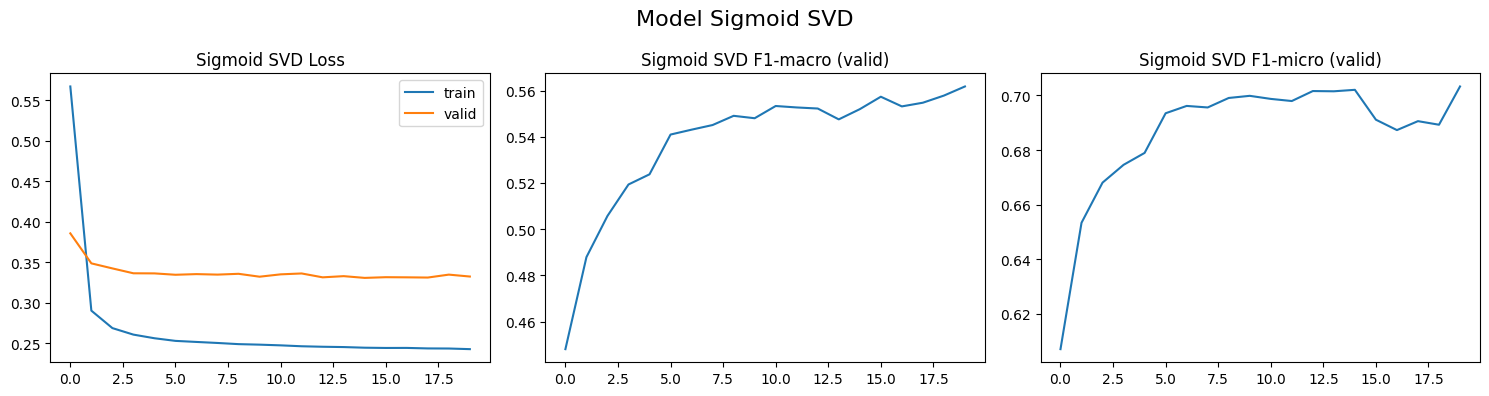


Sigmoid SVD — Test Results
F1-macro (macro t): 0.5478
F1-micro (macro t): 0.6753
F1-macro (micro t): 0.5286
F1-micro (micro t): 0.7046


In [161]:
res_sigmoid = run_experiment('Sigmoid SVD', model = model, optimizer = optimizer,
               X_train=X_train, y_train=y_train,
               X_valid=X_valid, y_valid=y_valid,
               X_test=X_test, y_test=y_test)

Заменить активацию на Softmax, а функцию потерь на кросс-энтропию, переобучить модель при тех же условиях, измерить качество и сделать выводы о причинах его изменения:

Переопределим модель:

In [162]:
class Model(nn.Module):
    def __init__(self, embedding_dim, num_labels):
        super().__init__()
        self.linear = nn.Linear(embedding_dim, num_labels)
        self.softmax = nn.Softmax(dim=1)
    def forward(self, x):
        return self.softmax(self.linear(x))

Новая функция потерь:

In [163]:
loss_fn = torch.nn.CrossEntropyLoss()

Пересоздадим модель, привяжем оптимизатор к ее параметрам:

In [164]:
model = Model(embedding_dim=200, num_labels=num_classes).to('cuda:0')
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

Теперь полностью повторим цикл обучения:

Softmax SVD Iter #0 Time 4s Train loss: 9.2139 Valid loss: 10.5862 Test F1-micro: 0.51 Test F1-macro: 0.27
Softmax SVD Iter #1 Time 0s Train loss: 9.1633 Valid loss: 10.5587 Test F1-micro: 0.50 Test F1-macro: 0.28
Softmax SVD Iter #2 Time 0s Train loss: 9.1559 Valid loss: 10.5556 Test F1-micro: 0.50 Test F1-macro: 0.28
Softmax SVD Iter #3 Time 0s Train loss: 9.1510 Valid loss: 10.5468 Test F1-micro: 0.51 Test F1-macro: 0.30
Softmax SVD Iter #4 Time 0s Train loss: 9.1472 Valid loss: 10.5429 Test F1-micro: 0.50 Test F1-macro: 0.29
Softmax SVD Iter #5 Time 3s Train loss: 9.1457 Valid loss: 10.5401 Test F1-micro: 0.51 Test F1-macro: 0.30
Softmax SVD Iter #6 Time 0s Train loss: 9.1441 Valid loss: 10.5412 Test F1-micro: 0.51 Test F1-macro: 0.29
Softmax SVD Iter #7 Time 0s Train loss: 9.1419 Valid loss: 10.5423 Test F1-micro: 0.50 Test F1-macro: 0.29
Softmax SVD Iter #8 Time 0s Train loss: 9.1407 Valid loss: 10.5379 Test F1-micro: 0.51 Test F1-macro: 0.29
Softmax SVD Iter #9 Time 0s Train los

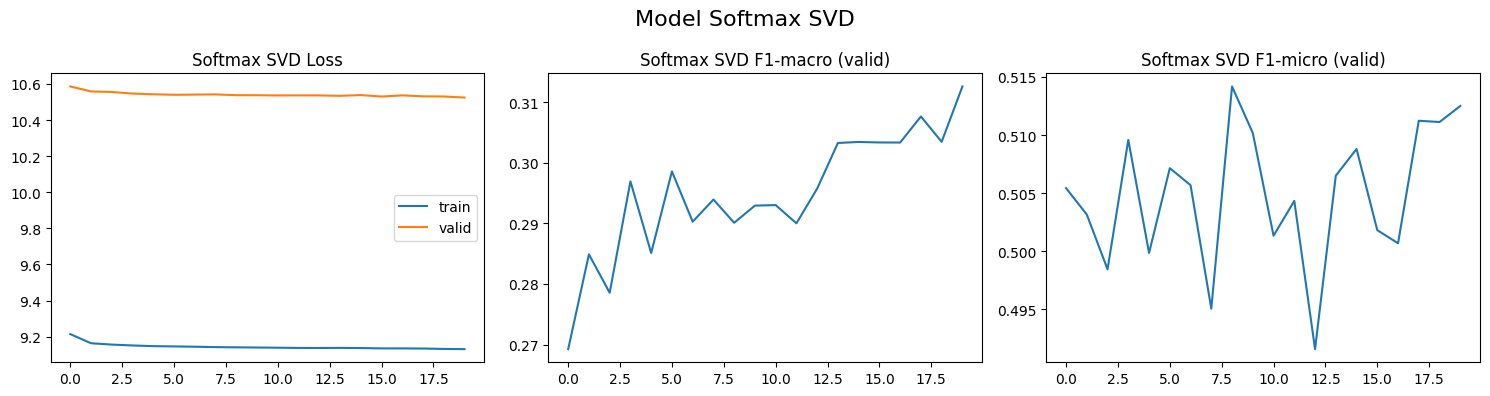


Softmax SVD — Test Results
F1-macro (macro t): 0.3133
F1-micro (macro t): 0.5022
F1-macro (micro t): 0.3133
F1-micro (micro t): 0.5022


In [165]:
res_softmax = run_experiment('Softmax SVD', model = model, optimizer = optimizer, loss_fn =loss_fn,
               X_train=X_train, y_train=y_train,
               X_valid=X_valid, y_valid=y_valid,
               X_test=X_test, y_test=y_test)

**Выводы**
- Так как решается задача мультилейбл классификации, то оптимальней использовать сигмоиду как функцию выхода и BCE, а не софтмакс и кросс энтропию, это связано с тем, что в данной задаче классы не связаны, они не обязательно взаимоисключающие
- Это подтверждается результатами, сигмоида справляется гораздо лучше, при этом обучение довольно быстро выходит на плато
- Софтмакс очень плохо справляется с задачей, а модель почти не обучается, по времени эпохи быстрее

__Задание 4 (5 баллов):__ Провести ряд экспериментов по улучшению качества работы модели, попробовать следующие идеи:

- варьирование числа и размера линейных слоёв
- использование различных функций активации между слоями
- выбор другого оптимизатора, варьирование его важных гиперпараметров
- замена векторизатора на BERT

Эксперименты должны быть подкреплены понятными графиками, таблицами, пояснениями причин такого выбора гиперпараметров и выводов на основе проделанной работы. Балл за задание определяется по четырём критериям:

- адекватность и полнота экспериментов
- качество отчета и выводов
- итоговое значение качества работы модели на тестовой выборке
- скорость сходимости лосса к целевому значению

Проведем следующие эксперименты:

**Архитектура модели**

Изучим, сильно ли влияет количество слоев в модели на результаты, для этого создадим модели с 1,2,3 слоями, между слоями будем использовать `ReLU`, на выходе сети - сигмоиду

На выходе используем именно сигмоиду, так как она больше подходит мультилейбл классификации, софтмакс правильней прменять для взаимоисключающей классификации 

In [166]:
class OneLayer(nn.Module):
    def __init__(self, input_dim, num_labels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, num_labels),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class TwoLayer(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_labels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_labels),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class ThreeLayer(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, num_labels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_labels),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

PS: вообще можно с помощью nn.Sequenstional, но его вроде на парах не рассказывали

Теперь запустим эксперименты:

1layer Iter #0 Time 4s Train loss: 0.3299 Valid loss: 0.3801 Test F1-micro: 0.69 Test F1-macro: 0.55
1layer Iter #1 Time 0s Train loss: 0.3030 Valid loss: 0.3854 Test F1-micro: 0.68 Test F1-macro: 0.55
1layer Iter #2 Time 0s Train loss: 0.3052 Valid loss: 0.3917 Test F1-micro: 0.68 Test F1-macro: 0.55
1layer Iter #3 Time 0s Train loss: 0.3070 Valid loss: 0.4224 Test F1-micro: 0.69 Test F1-macro: 0.56
1layer Iter #4 Time 0s Train loss: 0.3040 Valid loss: 0.4225 Test F1-micro: 0.69 Test F1-macro: 0.56
1layer Iter #5 Time 4s Train loss: 0.3047 Valid loss: 0.4216 Test F1-micro: 0.69 Test F1-macro: 0.57
1layer Iter #6 Time 0s Train loss: 0.3052 Valid loss: 0.4305 Test F1-micro: 0.68 Test F1-macro: 0.56
1layer Iter #7 Time 0s Train loss: 0.3094 Valid loss: 0.4295 Test F1-micro: 0.68 Test F1-macro: 0.56
1layer Iter #8 Time 0s Train loss: 0.3108 Valid loss: 0.4377 Test F1-micro: 0.68 Test F1-macro: 0.56
1layer Iter #9 Time 0s Train loss: 0.3063 Valid loss: 0.4086 Test F1-micro: 0.69 Test F1-ma

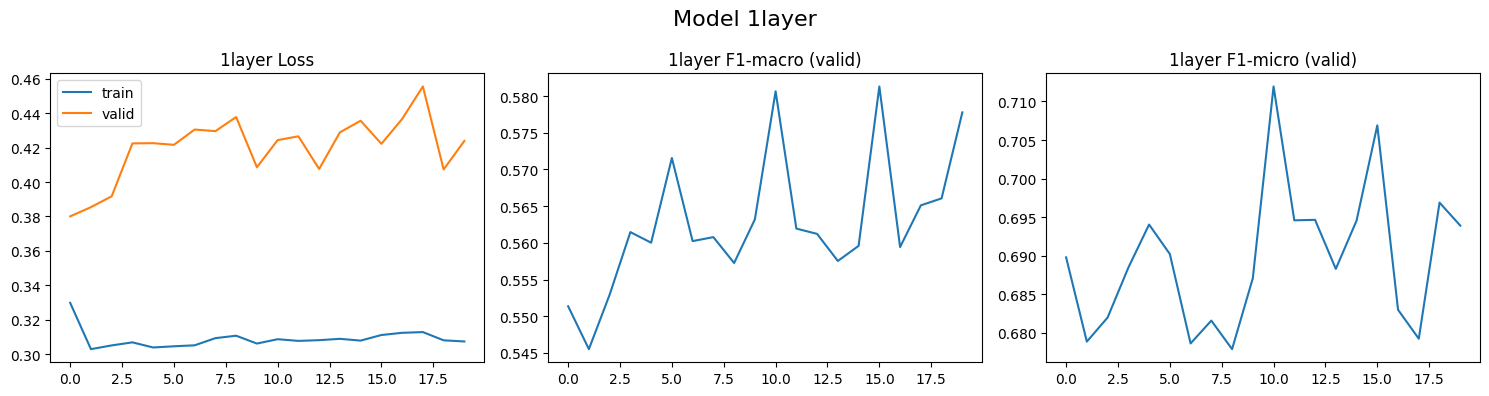


1layer — Test Results
F1-macro (macro t): 0.5437
F1-micro (macro t): 0.6471
F1-macro (micro t): 0.5252
F1-micro (micro t): 0.6938


In [170]:
results = []

model = OneLayer(200, num_classes).to(device)
res = run_experiment('1layer', model, torch.optim.Adam(model.parameters(), lr=0.005),
                     X_train, y_train, X_valid, y_valid, X_test, y_test)
results.append(res)

Два слоя разных размеров:

2layer_128 Iter #0 Time 4s Train loss: 0.2249 Valid loss: 0.2429 Test F1-micro: 0.75 Test F1-macro: 0.60
2layer_128 Iter #1 Time 1s Train loss: 0.1836 Valid loss: 0.2388 Test F1-micro: 0.74 Test F1-macro: 0.60
2layer_128 Iter #2 Time 0s Train loss: 0.1759 Valid loss: 0.2450 Test F1-micro: 0.73 Test F1-macro: 0.60
2layer_128 Iter #3 Time 1s Train loss: 0.1693 Valid loss: 0.2382 Test F1-micro: 0.74 Test F1-macro: 0.61
2layer_128 Iter #4 Time 1s Train loss: 0.1655 Valid loss: 0.2384 Test F1-micro: 0.75 Test F1-macro: 0.61
2layer_128 Iter #5 Time 4s Train loss: 0.1627 Valid loss: 0.2338 Test F1-micro: 0.75 Test F1-macro: 0.62
2layer_128 Iter #6 Time 0s Train loss: 0.1609 Valid loss: 0.2359 Test F1-micro: 0.76 Test F1-macro: 0.61
2layer_128 Iter #7 Time 0s Train loss: 0.1585 Valid loss: 0.2425 Test F1-micro: 0.75 Test F1-macro: 0.60
2layer_128 Iter #8 Time 0s Train loss: 0.1562 Valid loss: 0.2433 Test F1-micro: 0.75 Test F1-macro: 0.61
2layer_128 Iter #9 Time 1s Train loss: 0.1568 Valid los

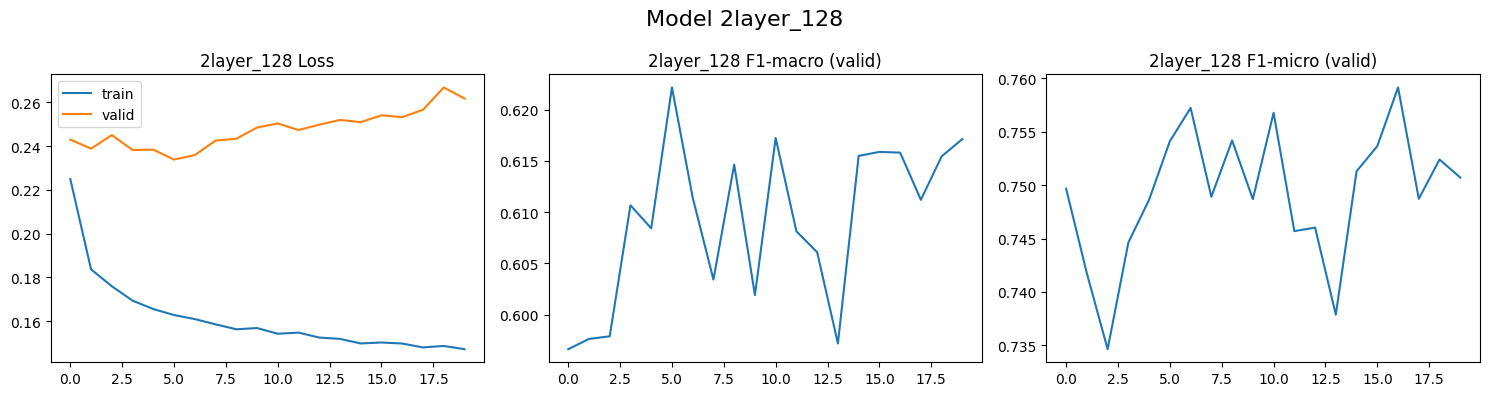


2layer_128 — Test Results
F1-macro (macro t): 0.5619
F1-micro (macro t): 0.6745
F1-macro (micro t): 0.5546
F1-micro (micro t): 0.7165
2layer_256 Iter #0 Time 4s Train loss: 0.2259 Valid loss: 0.2374 Test F1-micro: 0.74 Test F1-macro: 0.61
2layer_256 Iter #1 Time 0s Train loss: 0.1824 Valid loss: 0.2460 Test F1-micro: 0.74 Test F1-macro: 0.60
2layer_256 Iter #2 Time 1s Train loss: 0.1723 Valid loss: 0.2463 Test F1-micro: 0.74 Test F1-macro: 0.60
2layer_256 Iter #3 Time 0s Train loss: 0.1694 Valid loss: 0.2392 Test F1-micro: 0.74 Test F1-macro: 0.61
2layer_256 Iter #4 Time 0s Train loss: 0.1646 Valid loss: 0.2428 Test F1-micro: 0.74 Test F1-macro: 0.62
2layer_256 Iter #5 Time 4s Train loss: 0.1591 Valid loss: 0.2446 Test F1-micro: 0.77 Test F1-macro: 0.64
2layer_256 Iter #6 Time 0s Train loss: 0.1554 Valid loss: 0.2559 Test F1-micro: 0.76 Test F1-macro: 0.60
2layer_256 Iter #7 Time 0s Train loss: 0.1557 Valid loss: 0.2639 Test F1-micro: 0.76 Test F1-macro: 0.62
2layer_256 Iter #8 Time 0

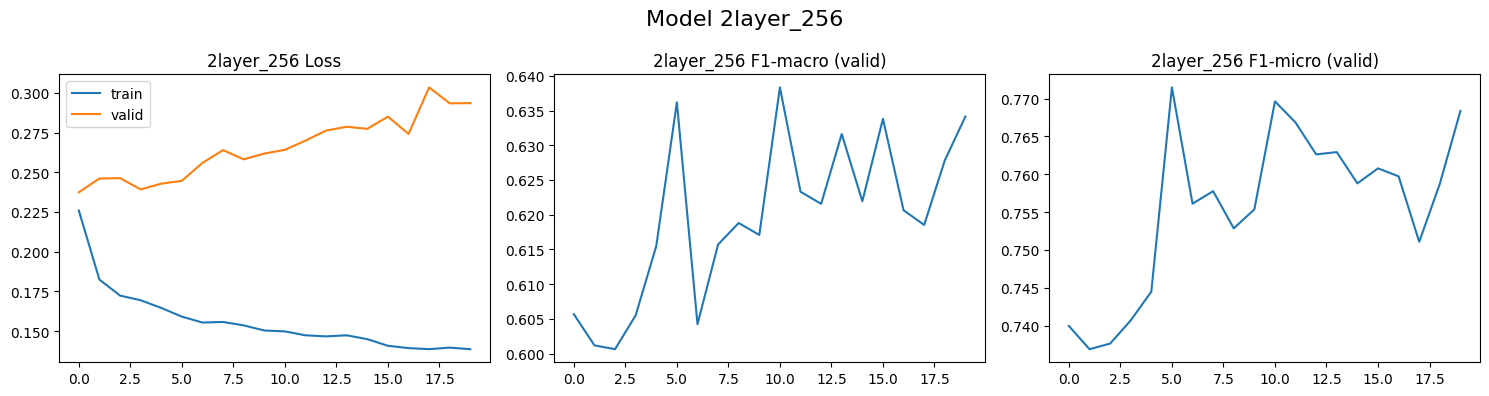


2layer_256 — Test Results
F1-macro (macro t): 0.5700
F1-micro (macro t): 0.6988
F1-macro (micro t): 0.5579
F1-micro (micro t): 0.7129
2layer_512 Iter #0 Time 4s Train loss: 0.2266 Valid loss: 0.2392 Test F1-micro: 0.75 Test F1-macro: 0.61
2layer_512 Iter #1 Time 0s Train loss: 0.1833 Valid loss: 0.2471 Test F1-micro: 0.74 Test F1-macro: 0.61
2layer_512 Iter #2 Time 0s Train loss: 0.1784 Valid loss: 0.2632 Test F1-micro: 0.74 Test F1-macro: 0.61
2layer_512 Iter #3 Time 0s Train loss: 0.1726 Valid loss: 0.2546 Test F1-micro: 0.74 Test F1-macro: 0.62
2layer_512 Iter #4 Time 0s Train loss: 0.1674 Valid loss: 0.2615 Test F1-micro: 0.75 Test F1-macro: 0.62
2layer_512 Iter #5 Time 4s Train loss: 0.1639 Valid loss: 0.2747 Test F1-micro: 0.76 Test F1-macro: 0.64
2layer_512 Iter #6 Time 0s Train loss: 0.1639 Valid loss: 0.2787 Test F1-micro: 0.75 Test F1-macro: 0.62
2layer_512 Iter #7 Time 0s Train loss: 0.1586 Valid loss: 0.2804 Test F1-micro: 0.76 Test F1-macro: 0.62
2layer_512 Iter #8 Time 0

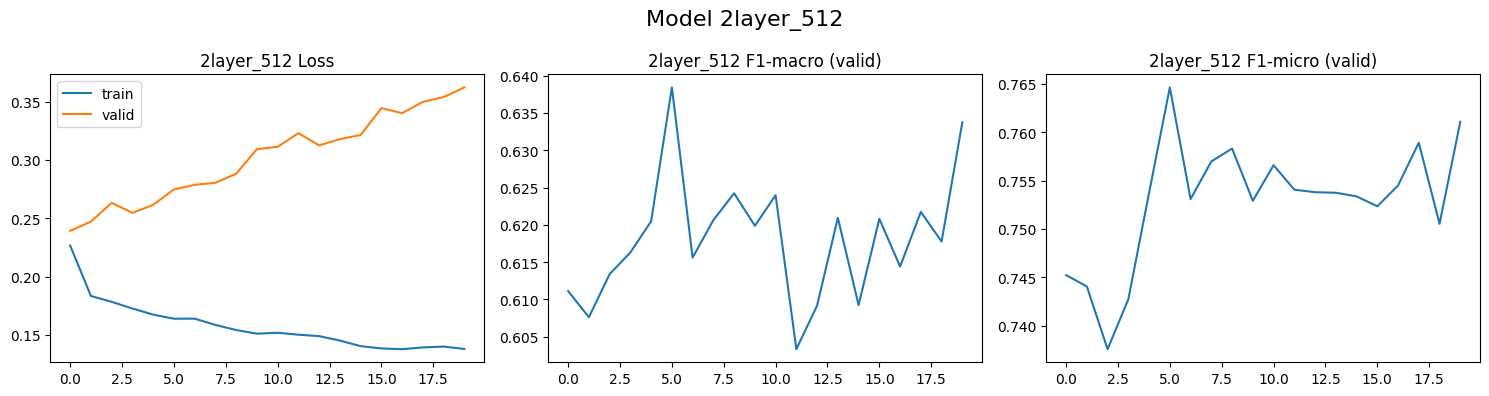


2layer_512 — Test Results
F1-macro (macro t): 0.5653
F1-micro (macro t): 0.6871
F1-macro (micro t): 0.5567
F1-micro (micro t): 0.7245


In [171]:
for hidden in [128, 256, 512]:
    model = TwoLayer(200, hidden, num_classes).to(device)
    res = run_experiment(f'2layer_{hidden}', model, torch.optim.Adam(model.parameters(), lr=0.004),
                         X_train, y_train, X_valid, y_valid, X_test, y_test)
    results.append(res)

**Вывод**
- Количество слоев влияет на качество модели, чем больше слоев, тем лучше ее обобщающая способность
- Оптимальная конфигурация - два слоя с размером скрытого слоя 256, увеличение до 512 не помогает и даже чуть хуже, что говорит о переобучении при большем числе параметров
- Нет смысла брать сильно большим размер скрытого слоя, так как даже после лучшей эпохи прирост в качестве небольшой

**Функции активации**

Напишем следующий класс:

In [172]:
class TwoLayerActivation(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_labels, activation):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            activation,
            nn.Linear(hidden_dim, num_labels),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

Посмотрим на эти активации:

In [173]:
activations = {
    'ReLU':  nn.ReLU(),
    'Tanh':  nn.Tanh(),
    'GELU':  nn.GELU(),
    'LeakyReLU': nn.LeakyReLU(),
}

Эксперименты:

2layer_256_ReLU Iter #0 Time 4s Train loss: 0.2569 Valid loss: 0.2579 Test F1-micro: 0.73 Test F1-macro: 0.58
2layer_256_ReLU Iter #1 Time 1s Train loss: 0.1928 Valid loss: 0.2374 Test F1-micro: 0.74 Test F1-macro: 0.60
2layer_256_ReLU Iter #2 Time 0s Train loss: 0.1763 Valid loss: 0.2256 Test F1-micro: 0.75 Test F1-macro: 0.62
2layer_256_ReLU Iter #3 Time 1s Train loss: 0.1668 Valid loss: 0.2258 Test F1-micro: 0.75 Test F1-macro: 0.63
2layer_256_ReLU Iter #4 Time 0s Train loss: 0.1597 Valid loss: 0.2252 Test F1-micro: 0.76 Test F1-macro: 0.63
2layer_256_ReLU Iter #5 Time 4s Train loss: 0.1542 Valid loss: 0.2264 Test F1-micro: 0.77 Test F1-macro: 0.64
2layer_256_ReLU Iter #6 Time 1s Train loss: 0.1505 Valid loss: 0.2273 Test F1-micro: 0.76 Test F1-macro: 0.64
2layer_256_ReLU Iter #7 Time 1s Train loss: 0.1467 Valid loss: 0.2353 Test F1-micro: 0.76 Test F1-macro: 0.64
2layer_256_ReLU Iter #8 Time 0s Train loss: 0.1435 Valid loss: 0.2347 Test F1-micro: 0.77 Test F1-macro: 0.64
2layer_256

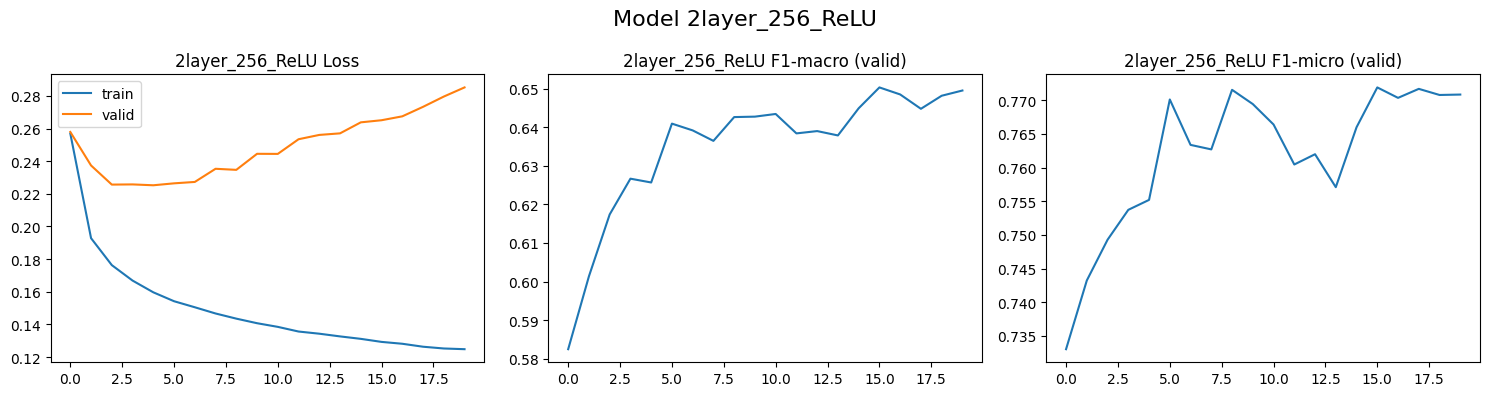


2layer_256_ReLU — Test Results
F1-macro (macro t): 0.5929
F1-micro (macro t): 0.7087
F1-macro (micro t): 0.5881
F1-micro (micro t): 0.7238
2layer_256_Tanh Iter #0 Time 4s Train loss: 0.2181 Valid loss: 0.2224 Test F1-micro: 0.74 Test F1-macro: 0.60
2layer_256_Tanh Iter #1 Time 0s Train loss: 0.1718 Valid loss: 0.2111 Test F1-micro: 0.74 Test F1-macro: 0.61
2layer_256_Tanh Iter #2 Time 1s Train loss: 0.1608 Valid loss: 0.2051 Test F1-micro: 0.75 Test F1-macro: 0.62
2layer_256_Tanh Iter #3 Time 1s Train loss: 0.1535 Valid loss: 0.2011 Test F1-micro: 0.76 Test F1-macro: 0.63
2layer_256_Tanh Iter #4 Time 0s Train loss: 0.1480 Valid loss: 0.2003 Test F1-micro: 0.76 Test F1-macro: 0.63
2layer_256_Tanh Iter #5 Time 4s Train loss: 0.1436 Valid loss: 0.2033 Test F1-micro: 0.77 Test F1-macro: 0.64
2layer_256_Tanh Iter #6 Time 0s Train loss: 0.1397 Valid loss: 0.2018 Test F1-micro: 0.77 Test F1-macro: 0.64
2layer_256_Tanh Iter #7 Time 0s Train loss: 0.1366 Valid loss: 0.1995 Test F1-micro: 0.77 

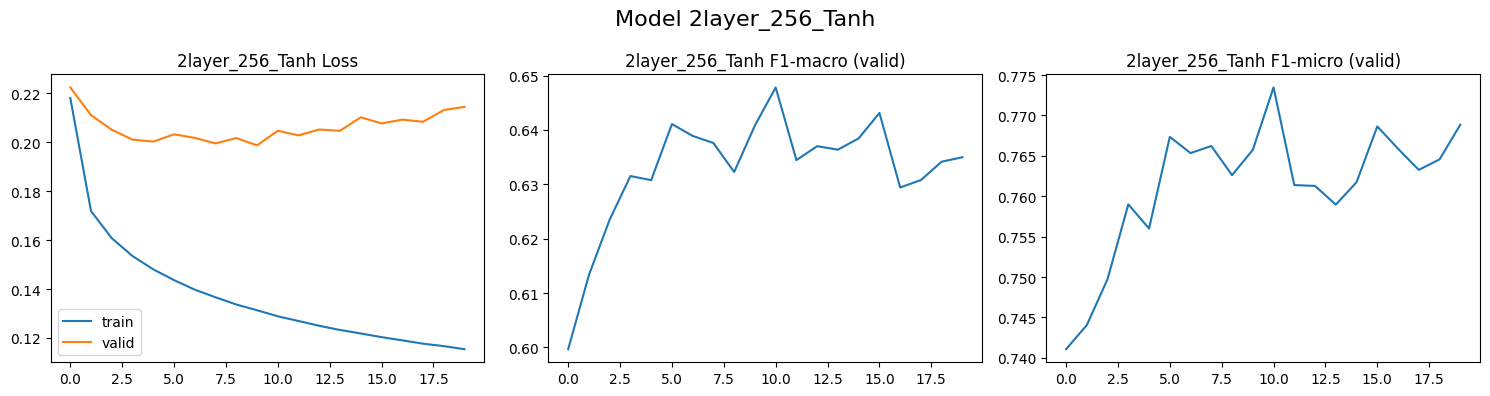


2layer_256_Tanh — Test Results
F1-macro (macro t): 0.5884
F1-micro (macro t): 0.7233
F1-macro (micro t): 0.5575
F1-micro (micro t): 0.7338
2layer_256_GELU Iter #0 Time 4s Train loss: 0.2595 Valid loss: 0.2603 Test F1-micro: 0.72 Test F1-macro: 0.58
2layer_256_GELU Iter #1 Time 0s Train loss: 0.1964 Valid loss: 0.2393 Test F1-micro: 0.74 Test F1-macro: 0.61
2layer_256_GELU Iter #2 Time 0s Train loss: 0.1781 Valid loss: 0.2315 Test F1-micro: 0.74 Test F1-macro: 0.61
2layer_256_GELU Iter #3 Time 0s Train loss: 0.1667 Valid loss: 0.2278 Test F1-micro: 0.76 Test F1-macro: 0.62
2layer_256_GELU Iter #4 Time 0s Train loss: 0.1601 Valid loss: 0.2253 Test F1-micro: 0.75 Test F1-macro: 0.62
2layer_256_GELU Iter #5 Time 4s Train loss: 0.1545 Valid loss: 0.2226 Test F1-micro: 0.76 Test F1-macro: 0.64
2layer_256_GELU Iter #6 Time 0s Train loss: 0.1496 Valid loss: 0.2273 Test F1-micro: 0.75 Test F1-macro: 0.63
2layer_256_GELU Iter #7 Time 0s Train loss: 0.1462 Valid loss: 0.2329 Test F1-micro: 0.75 

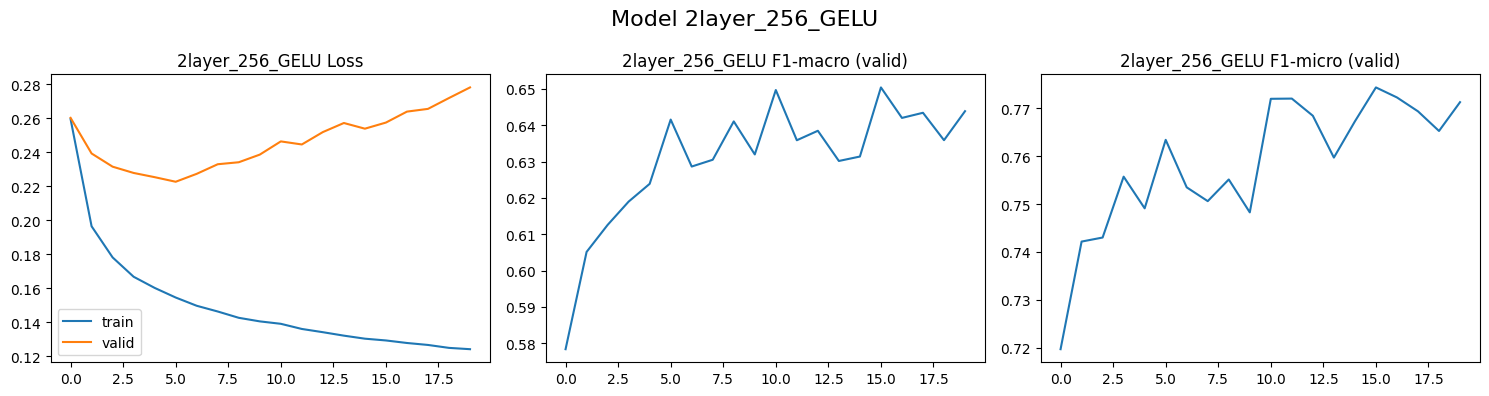


2layer_256_GELU — Test Results
F1-macro (macro t): 0.5934
F1-micro (macro t): 0.7157
F1-macro (micro t): 0.5838
F1-micro (micro t): 0.7294
2layer_256_LeakyReLU Iter #0 Time 4s Train loss: 0.2605 Valid loss: 0.2662 Test F1-micro: 0.72 Test F1-macro: 0.57
2layer_256_LeakyReLU Iter #1 Time 1s Train loss: 0.1965 Valid loss: 0.2414 Test F1-micro: 0.73 Test F1-macro: 0.60
2layer_256_LeakyReLU Iter #2 Time 1s Train loss: 0.1792 Valid loss: 0.2316 Test F1-micro: 0.73 Test F1-macro: 0.61
2layer_256_LeakyReLU Iter #3 Time 1s Train loss: 0.1682 Valid loss: 0.2267 Test F1-micro: 0.74 Test F1-macro: 0.62
2layer_256_LeakyReLU Iter #4 Time 0s Train loss: 0.1616 Valid loss: 0.2328 Test F1-micro: 0.75 Test F1-macro: 0.63
2layer_256_LeakyReLU Iter #5 Time 4s Train loss: 0.1563 Valid loss: 0.2279 Test F1-micro: 0.77 Test F1-macro: 0.64
2layer_256_LeakyReLU Iter #6 Time 1s Train loss: 0.1518 Valid loss: 0.2327 Test F1-micro: 0.76 Test F1-macro: 0.64
2layer_256_LeakyReLU Iter #7 Time 1s Train loss: 0.1479

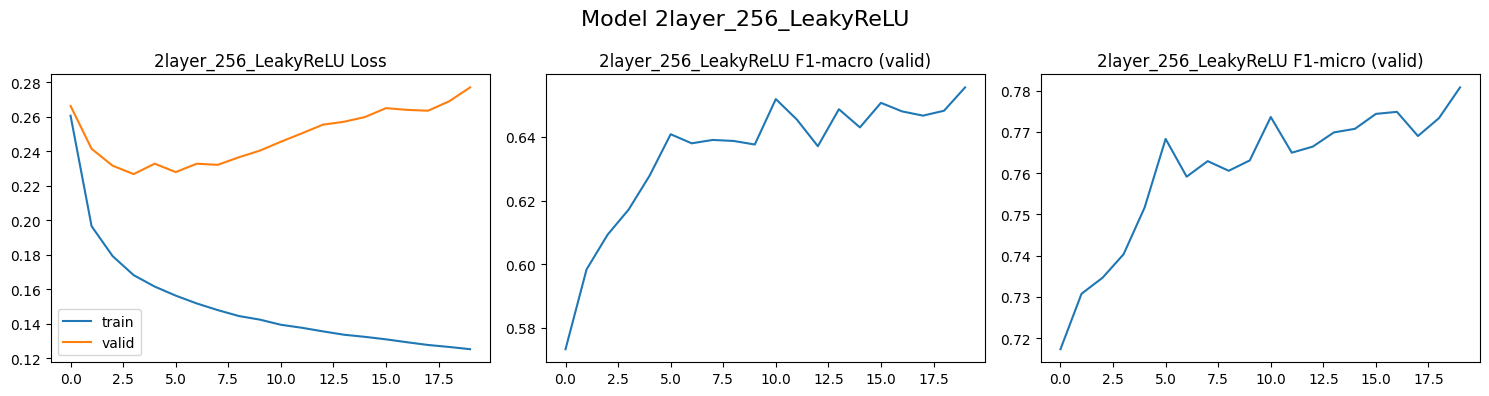


2layer_256_LeakyReLU — Test Results
F1-macro (macro t): 0.5972
F1-micro (macro t): 0.7293
F1-macro (micro t): 0.5881
F1-micro (micro t): 0.7419


In [175]:
results_act = []
for act_name, activation in activations.items():
    model = TwoLayerActivation(200, 256, num_classes, activation).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    res = run_experiment(f'2layer_256_{act_name}', model, optimizer,
                         X_train, y_train, X_valid, y_valid, X_test, y_test)
    results_act.append(res)

**Вывод**
- Использование любой активации и двух слоев лучше бейзлайн решения с одним слоем
- Лусшая активация `LeakyReLU`, это понятно, так как в отличие от `ReLU` она не зануляет отрицательные градиенты
- `ReLU` и `GELU` почти одинаковы 
- `Tanh` хуже по F1-макро (0.588) но лучше по F1-микро, имеет самый плоский профиль валидационного лосса

**Оптимизаторы**

Выберем с прошлых пуктов лучшую конфигурацию и посмотрим на различные методы оптимизации

In [17]:
class TwoLayerLeakyReLU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_labels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, num_labels),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

Смотрим следующие методы оптимизации:

In [177]:
optimizers_cfg = [
    ('AdamW_lr1e-3', lambda p: torch.optim.AdamW(p, lr=1e-3, betas=(0.9, 0.98))),
    ('AdamW_lr1e-4', lambda p: torch.optim.AdamW(p, lr=1e-4, betas=(0.9, 0.98))),
    ('Adam_lr1e-3', lambda p: torch.optim.Adam(p, lr=1e-3)),
    ('SGD_momentum', lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9)),
    ('SGD_simple', lambda p: torch.optim.SGD(p, lr=0.01)),
]

LeakyReLU_AdamW_lr1e-3 Iter #0 Time 4s Train loss: 0.2562 Valid loss: 0.2593 Test F1-micro: 0.72 Test F1-macro: 0.58
LeakyReLU_AdamW_lr1e-3 Iter #1 Time 0s Train loss: 0.1924 Valid loss: 0.2340 Test F1-micro: 0.74 Test F1-macro: 0.60
LeakyReLU_AdamW_lr1e-3 Iter #2 Time 0s Train loss: 0.1743 Valid loss: 0.2255 Test F1-micro: 0.75 Test F1-macro: 0.61
LeakyReLU_AdamW_lr1e-3 Iter #3 Time 0s Train loss: 0.1635 Valid loss: 0.2266 Test F1-micro: 0.74 Test F1-macro: 0.62
LeakyReLU_AdamW_lr1e-3 Iter #4 Time 0s Train loss: 0.1566 Valid loss: 0.2288 Test F1-micro: 0.75 Test F1-macro: 0.62
LeakyReLU_AdamW_lr1e-3 Iter #5 Time 4s Train loss: 0.1513 Valid loss: 0.2300 Test F1-micro: 0.77 Test F1-macro: 0.64
LeakyReLU_AdamW_lr1e-3 Iter #6 Time 0s Train loss: 0.1467 Valid loss: 0.2339 Test F1-micro: 0.77 Test F1-macro: 0.63
LeakyReLU_AdamW_lr1e-3 Iter #7 Time 0s Train loss: 0.1432 Valid loss: 0.2385 Test F1-micro: 0.76 Test F1-macro: 0.63
LeakyReLU_AdamW_lr1e-3 Iter #8 Time 1s Train loss: 0.1400 Valid 

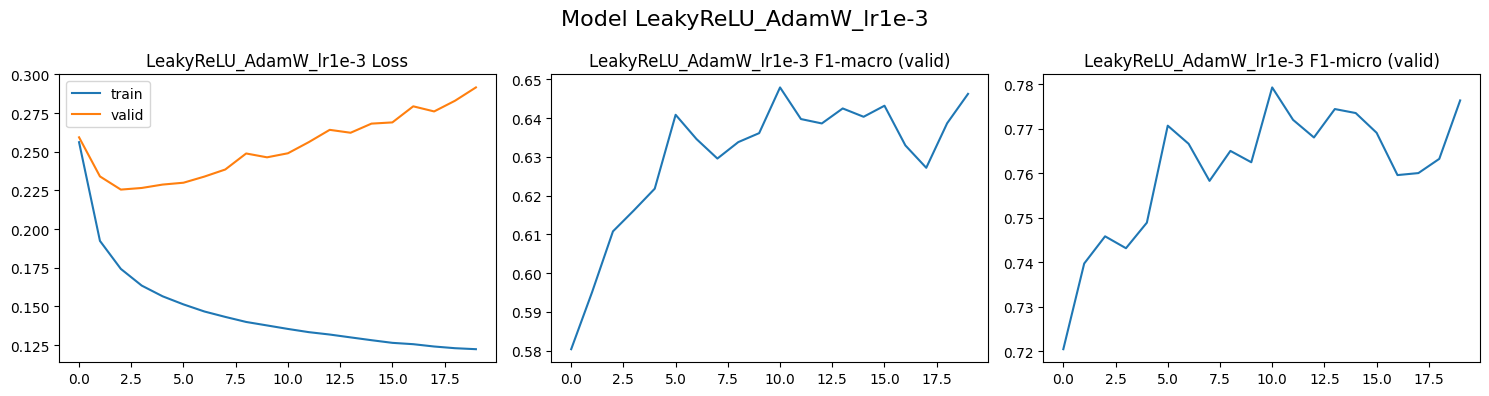


LeakyReLU_AdamW_lr1e-3 — Test Results
F1-macro (macro t): 0.5976
F1-micro (macro t): 0.7311
F1-macro (micro t): 0.5773
F1-micro (micro t): 0.7396
LeakyReLU_AdamW_lr1e-4 Iter #0 Time 4s Train loss: 0.3987 Valid loss: 0.3590 Test F1-micro: 0.57 Test F1-macro: 0.43
LeakyReLU_AdamW_lr1e-4 Iter #1 Time 0s Train loss: 0.2707 Valid loss: 0.3140 Test F1-micro: 0.62 Test F1-macro: 0.48
LeakyReLU_AdamW_lr1e-4 Iter #2 Time 0s Train loss: 0.2437 Valid loss: 0.2935 Test F1-micro: 0.64 Test F1-macro: 0.50
LeakyReLU_AdamW_lr1e-4 Iter #3 Time 0s Train loss: 0.2293 Valid loss: 0.2813 Test F1-micro: 0.65 Test F1-macro: 0.52
LeakyReLU_AdamW_lr1e-4 Iter #4 Time 0s Train loss: 0.2191 Valid loss: 0.2729 Test F1-micro: 0.66 Test F1-macro: 0.53
LeakyReLU_AdamW_lr1e-4 Iter #5 Time 4s Train loss: 0.2114 Valid loss: 0.2679 Test F1-micro: 0.72 Test F1-macro: 0.57
LeakyReLU_AdamW_lr1e-4 Iter #6 Time 0s Train loss: 0.2054 Valid loss: 0.2612 Test F1-micro: 0.71 Test F1-macro: 0.57
LeakyReLU_AdamW_lr1e-4 Iter #7 Tim

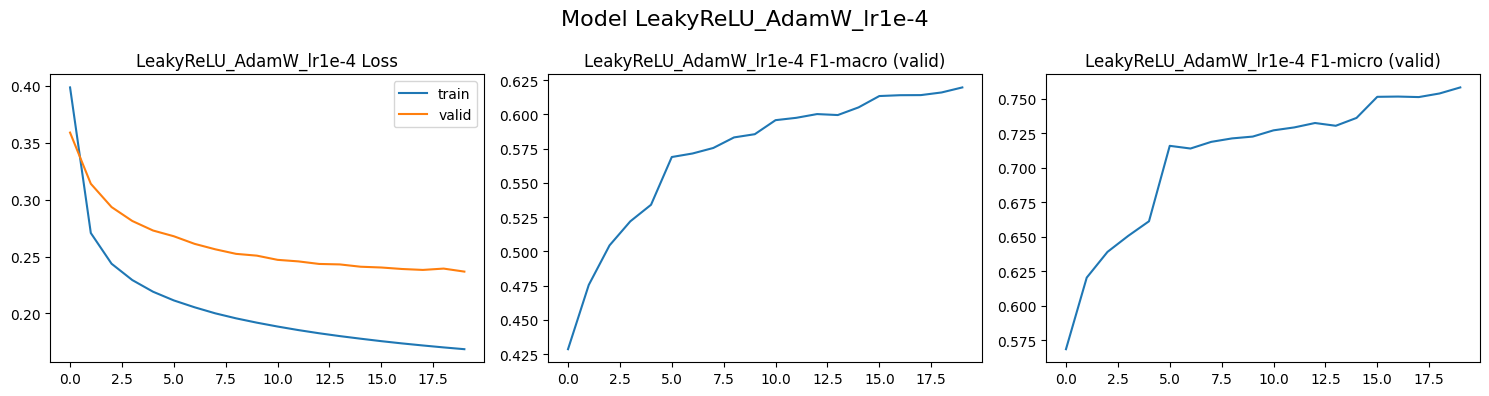


LeakyReLU_AdamW_lr1e-4 — Test Results
F1-macro (macro t): 0.5868
F1-micro (macro t): 0.7196
F1-macro (micro t): 0.5579
F1-micro (micro t): 0.7368
LeakyReLU_Adam_lr1e-3 Iter #0 Time 4s Train loss: 0.2586 Valid loss: 0.2598 Test F1-micro: 0.73 Test F1-macro: 0.58
LeakyReLU_Adam_lr1e-3 Iter #1 Time 0s Train loss: 0.1953 Valid loss: 0.2367 Test F1-micro: 0.75 Test F1-macro: 0.60
LeakyReLU_Adam_lr1e-3 Iter #2 Time 0s Train loss: 0.1781 Valid loss: 0.2276 Test F1-micro: 0.75 Test F1-macro: 0.61
LeakyReLU_Adam_lr1e-3 Iter #3 Time 0s Train loss: 0.1677 Valid loss: 0.2280 Test F1-micro: 0.75 Test F1-macro: 0.61
LeakyReLU_Adam_lr1e-3 Iter #4 Time 0s Train loss: 0.1607 Valid loss: 0.2272 Test F1-micro: 0.76 Test F1-macro: 0.61
LeakyReLU_Adam_lr1e-3 Iter #5 Time 4s Train loss: 0.1551 Valid loss: 0.2300 Test F1-micro: 0.76 Test F1-macro: 0.63
LeakyReLU_Adam_lr1e-3 Iter #6 Time 1s Train loss: 0.1507 Valid loss: 0.2365 Test F1-micro: 0.75 Test F1-macro: 0.63
LeakyReLU_Adam_lr1e-3 Iter #7 Time 1s Tra

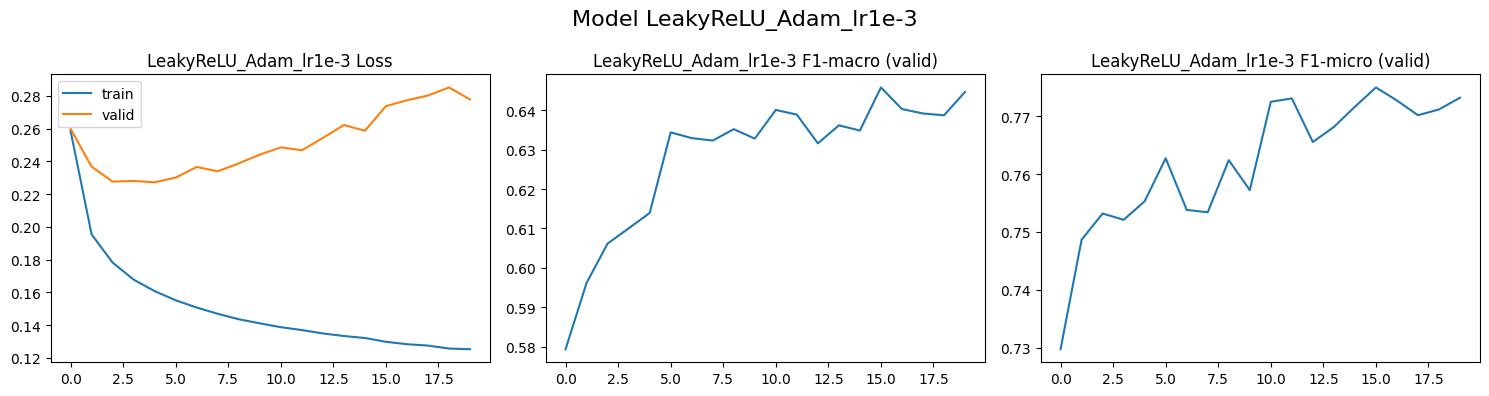


LeakyReLU_Adam_lr1e-3 — Test Results
F1-macro (macro t): 0.5907
F1-micro (macro t): 0.7155
F1-macro (micro t): 0.5788
F1-micro (micro t): 0.7244
LeakyReLU_SGD_momentum Iter #0 Time 4s Train loss: 0.3266 Valid loss: 0.3291 Test F1-micro: 0.61 Test F1-macro: 0.47
LeakyReLU_SGD_momentum Iter #1 Time 0s Train loss: 0.2546 Valid loss: 0.2958 Test F1-micro: 0.64 Test F1-macro: 0.50
LeakyReLU_SGD_momentum Iter #2 Time 0s Train loss: 0.2350 Valid loss: 0.2831 Test F1-micro: 0.65 Test F1-macro: 0.52
LeakyReLU_SGD_momentum Iter #3 Time 0s Train loss: 0.2234 Valid loss: 0.2731 Test F1-micro: 0.66 Test F1-macro: 0.54
LeakyReLU_SGD_momentum Iter #4 Time 0s Train loss: 0.2148 Valid loss: 0.2649 Test F1-micro: 0.67 Test F1-macro: 0.54
LeakyReLU_SGD_momentum Iter #5 Time 4s Train loss: 0.2086 Valid loss: 0.2611 Test F1-micro: 0.72 Test F1-macro: 0.57
LeakyReLU_SGD_momentum Iter #6 Time 0s Train loss: 0.2034 Valid loss: 0.2569 Test F1-micro: 0.73 Test F1-macro: 0.57
LeakyReLU_SGD_momentum Iter #7 Time

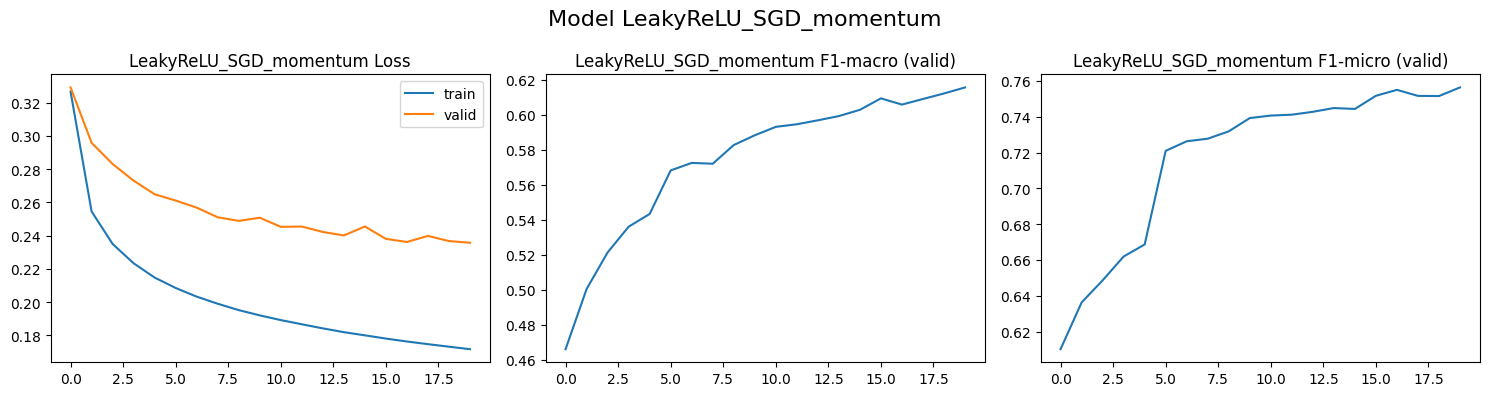


LeakyReLU_SGD_momentum — Test Results
F1-macro (macro t): 0.5728
F1-micro (macro t): 0.7092
F1-macro (micro t): 0.5510
F1-micro (micro t): 0.7374
LeakyReLU_SGD_simple Iter #0 Time 4s Train loss: 0.4277 Valid loss: 0.4392 Test F1-micro: 0.47 Test F1-macro: 0.36
LeakyReLU_SGD_simple Iter #1 Time 0s Train loss: 0.3469 Valid loss: 0.4017 Test F1-micro: 0.50 Test F1-macro: 0.37
LeakyReLU_SGD_simple Iter #2 Time 0s Train loss: 0.3229 Valid loss: 0.3805 Test F1-micro: 0.52 Test F1-macro: 0.38
LeakyReLU_SGD_simple Iter #3 Time 0s Train loss: 0.3079 Valid loss: 0.3676 Test F1-micro: 0.54 Test F1-macro: 0.39
LeakyReLU_SGD_simple Iter #4 Time 0s Train loss: 0.2972 Valid loss: 0.3577 Test F1-micro: 0.55 Test F1-macro: 0.40
LeakyReLU_SGD_simple Iter #5 Time 4s Train loss: 0.2886 Valid loss: 0.3491 Test F1-micro: 0.59 Test F1-macro: 0.45
LeakyReLU_SGD_simple Iter #6 Time 0s Train loss: 0.2817 Valid loss: 0.3403 Test F1-micro: 0.60 Test F1-macro: 0.46
LeakyReLU_SGD_simple Iter #7 Time 0s Train loss:

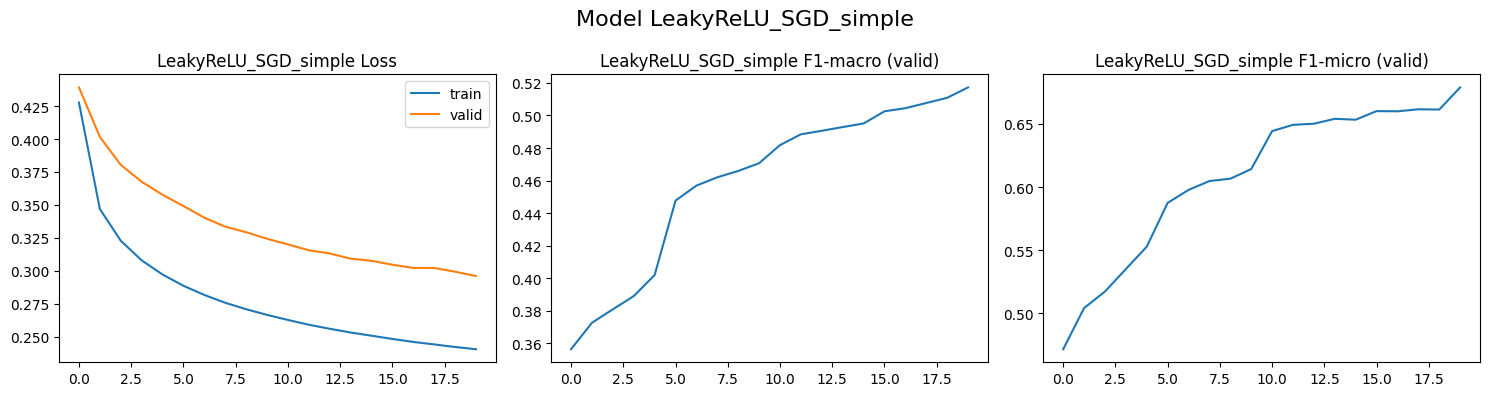


LeakyReLU_SGD_simple — Test Results
F1-macro (macro t): 0.4985
F1-micro (macro t): 0.6461
F1-macro (micro t): 0.4748
F1-micro (micro t): 0.6724


In [179]:
results_opt = []
for opt_name, opt_fn in optimizers_cfg:
    model = TwoLayerLeakyReLU(200, 256, num_classes).to(device)
    optimizer = opt_fn(model.parameters())
    res = run_experiment(f'LeakyReLU_{opt_name}', model, optimizer,
                         X_train, y_train, X_valid, y_valid, X_test, y_test)
    results_opt.append(res)

**Вывод**
- скорость обучения (`lr`) сильно влияет на график лосса и помогает предотвратить переобучение
- Адаптивные оптимизаторы значительно превосходят SGD
- Момент важен для SGD, что видно по последним двум графикам
- AdamW стабильно превосходит Adam за счёт корректной L2-регуляризации весов,
- По макро метрикам лучший - `AdamW` с `lr=1e-3`

**Замена векторизатора**

На лучшую конфигурацию заменим векторизацию

In [18]:
name = 'intfloat/multilingual-e5-base'
vectorizer = BERTVectorizer(name, device='cuda:0')

Векторизуем данные лучшим способом из предыдуших пунктов:

In [ ]:
X_train_bert = vectorizer(dataset['train']['text'], averaging='mean')
X_valid_bert = vectorizer(dataset['validation']['text'], averaging='mean')
X_test_bert = vectorizer(dataset['test']['text'], averaging='mean')

# Сохранние
save_embeddings(f'embeddings/mean',
            names=['X_train', 'X_valid', 'X_test'],
            arrays=[X_train_bert, X_valid_bert, X_test_bert])

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


: 

Теперь достанем размерность:

In [ ]:
input_dim = X_train_bert.shape[1]
input_dim

Зададим модель:

In [ ]:
model_bert = TwoLayerLeakyReLU(input_dim, 256, num_classes).to(device)
optimizer_bert = torch.optim.AdamW(model_bert.parameters(), lr=1e-3)

NameError: name 'TwoLayerLeakyReLU' is not defined

In [ ]:
res_bert = run_experiment(
    'LeakyReLU_AdamW_BERT',
    model_bert, optimizer_bert,
    X_train_bert, y_train,
    X_valid_bert, y_valid,
    X_test_bert, y_test
)

__Дополнительное задание (10 баллов):__ В экспериментах выше документ представляется в виде одного вектора. В задании предлагается разобраться с базовой теорией сверточных нейронных сетей самостоятельно и выполнить следующие пункты:

- заменить это представление на по-токенное (т.е. документ - матрица векторов, по одному на каждый токен)
- в качестве векторов попробовать использовать выходы BERT или обучить модель Word2vec/FastText
- предложить и реализовать способ организации процесса векторизации и обучения, чтобы избавиться от проблемы различной длины документов
- попробовать в качестве первого слоя в модели одномерный сверточный слой с Global Max Pooling или K-max Pooling поверх его выходов
- провести любые иные улучшения модели с использованием свёрточных слоёв, слоёв пулинга, линейных слоёв и нелинейных активаций
- задокументировать все эксперименты и попытаться получить результаты выше, чем у лучше модели из основной части задания

**по-токенное представление через BERT**

Теперь будем брать все токены, а не один в векторизации:

In [ ]:
class BERTTokenVectorizer:
    def __init__(self, model_name, device='cuda:0', max_length=128):
        self.device = device
        self.max_length = max_length
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(device)
        self.model.eval()

    def vectorize_batch(self, texts):
        encoded = self.tokenizer(
            texts, padding='max_length', truncation=True,
            max_length=self.max_length,
            return_tensors='pt').to(self.device)
        with torch.no_grad():
            hidden_states = self.model(**encoded).last_hidden_state
        return hidden_states.cpu().float(), encoded['attention_mask'].cpu()

Получается, данные возращаются в формате (batch, max_length, hidden_dim) и маска

Так же надо написать новый датасет:

In [ ]:
class TokenDataset(Dataset):
    def __init__(self, token_embeddings, masks, labels):
        self.data= torch.tensor(token_embeddings, dtype=torch.float32)
        self.masks = torch.tensor(masks, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return  len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.masks[idx], self.labels[idx]

В условии была описана проблема разной длины документов, которые обрабатываются батчом, мы решим ее, используя паддинг

Но такое использование паддинга может сильно испортить свертки, так как в них будет много нулей, поэтому используем маску внимания из токенайзера, чтобы правильно делать свертки в нашем случае

Реализуем такую сверточную модель, она будет состоять из нескольких последовательных сверток с `ReLU`, так же добавим `dropout`:

In [ ]:
class TextCNN(nn.Module):
    def __init__(self, input_dim, num_filters, kernel_sizes, num_labels, dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=input_dim, out_channels=num_filters, kernel_size=k)
            for k in  kernel_sizes
        ])
        self.dropout= nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters *len(kernel_sizes), num_labels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, mask=None):
        x = x.transpose(1, 2)

        pooled =[]
        for conv in self.convs:
            out = torch.relu(conv(x))
            out = out.max(dim=2).values
            pooled.append(out)

        x = torch.cat(pooled, dim=1)
        x = self.dropout(x)
        x =self.sigmoid(self.fc(x))
        return x

In [ ]:
def run_experiment_cnn(name, model, optimizer, X_train, y_train, X_valid, y_valid,
                   X_test, y_test, loss_fn = nn.BCELoss(), num_epochs=num_epochs, threshold_every=thresh_every):
    
    best_f1 =-1
    best_thresholds = [0.5] * num_classes
    best_state = None

    train_loss_list, valid_loss_list = [], []
    f1_macro_list, f1_micro_list = [], []

    # Датасеты
    train_dataloader = DataLoader(TokenDataset(X_train,mask_train, y_train), batch_size=64, shuffle=True)
    valid_dataloader = DataLoader(TokenDataset(X_valid,mask_valid, y_valid), batch_size=64)
    test_dataloader = DataLoader(TokenDataset(X_test, mask_test, y_test),  batch_size=64)

    
    # Обучение
    for epoch in range(num_epochs):
        timestamp_start = time.time()

        # Тренировка
        model.train()
        train_losses = []
        for i, data in enumerate(train_dataloader):
            X_batch,mask_batch, y_batch = data
            X_batch,mask_batch, y_batch = X_batch.to(device), mask_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch, mask_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        train_loss_list.append(np.mean(train_losses))

        # Валидация
        model.eval()
        valid_losses = []
        valid_proba = []

        with torch.no_grad():
            for X_batch, mask_batch, y_batch in valid_dataloader:
                X_batch, mask_batch, y_batch = X_batch.to(device), mask_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch, mask_batch)
                valid_losses.append(loss_fn(y_pred, y_batch).item())
                valid_proba.append(y_pred.cpu().numpy())
        valid_loss_list.append(np.mean(valid_losses))
        valid_proba = np.vstack(valid_proba)

        # Пороги
        if epoch % threshold_every == 0 or epoch ==num_epochs - 1:
            best_thresholds = calculate_best_thresholds_from_proba(valid_proba, y_valid, average='macro')

        y_valid_pred = (valid_proba >= np.array(best_thresholds)).astype(int)
        f1_macro = f1_score(y_valid, y_valid_pred, average='macro')
        f1_micro = f1_score(y_valid, y_valid_pred, average='micro')
        f1_macro_list.append(f1_macro)
        f1_micro_list.append(f1_micro)

        # Лучшая модель
        if f1_macro > best_f1:
            best_f1 = f1_macro
            best_state= {k: v.clone() for k, v in model.state_dict().items()}

        print(
            f'{name} '    
            f'Iter #{epoch} '
            f'Time {round(time.time() - timestamp_start)}s '
            f'Train loss: {train_loss_list[-1]:.4f} '
            f'Valid loss: {valid_loss_list[-1]:.4f} '
            f'Test F1-micro: {f1_micro:.2f} '
            f'Test F1-macro: {f1_macro:.2f}'
            )

    # Тест лучшей
    model.load_state_dict(best_state)
    model.eval()
    test_proba = []
    with torch.no_grad():
        for X_batch, mask_batch, q in test_dataloader:
            test_proba.append(model(X_batch.to(device), mask_batch.to(device)).cpu().numpy())
    test_proba = np.vstack(test_proba)

    # Пороги
    thresholds_macro = calculate_best_thresholds_from_proba(valid_proba, y_valid, average='macro')
    thresholds_micro  = calculate_best_thresholds_from_proba(valid_proba, y_valid, average='micro')

    y_test_pred_macro = (test_proba >= np.array(thresholds_macro))
    y_test_pred_micro= (test_proba >= np.array(thresholds_micro))

    # Графики
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(train_loss_list, label='train')
    axes[0].plot(valid_loss_list, label='valid')
    axes[0].set_title(f'{name} Loss')
    axes[0].legend()
    axes[1].plot(f1_macro_list)
    axes[1].set_title(f'{name} F1-macro (valid)')
    axes[2].plot(f1_micro_list)
    axes[2].set_title(f'{name} F1-micro (valid)')
    plt.suptitle(f'Model {name}', fontsize=16)
    plt.tight_layout()
    plt.show()

    
    result =  {
        'name':name,
        'train_loss':train_loss_list,
        'valid_loss': valid_loss_list,
        'f1_macro_list': f1_macro_list,
        'f1_micro_list':f1_micro_list,
        'test_f1_macro (macro t)': round(f1_score(y_test, y_test_pred_macro, average='macro'),4),
        'test_f1_micro (macro t)': round(f1_score(y_test, y_test_pred_macro, average='micro'), 4),
        'test_f1_macro (micro t)': round(f1_score(y_test, y_test_pred_micro, average='macro'), 4),
        'test_f1_micro (micro t)': round(f1_score(y_test, y_test_pred_micro, average='micro'), 4)
    }

    print(f'\n{name} — Test Results')
    print(f'F1-macro (macro t): {result["test_f1_macro (macro t)"]:.4f}')
    print(f'F1-micro (macro t): {result["test_f1_micro (macro t)"]:.4f}')
    print(f'F1-macro (micro t): {result["test_f1_macro (micro t)"]:.4f}')
    print(f'F1-micro (micro t): {result["test_f1_micro (micro t)"]:.4f}')
    return result